# E-Commerce Consumer Behavior & Transaction Performance EDA 
**Objective:** End-to-end data auditing, cleaning, missing value imputation, outlier identification, and univariate/bivariate exploratory data analysis to derive actionable business insights.

# E-Commerce Consumer Behavior & Transaction Performance EDA 
**Objective:** End-to-end data auditing, cleaning, missing value imputation, outlier identification, and univariate/bivariate exploratory data analysis to derive actionable business insights.

## Library Imports
* Importing essential scientific computing, data manipulation, and visualization libraries.

In [56]:
import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()
import warnings
warnings.filterwarnings('ignore')

## Data Loading
* Loading the raw transaction dataset and previewing the top records.

In [2]:
# ecomm = pd.read_excel("C:/Users/Gaurav/Desktop/FBS/Data analysis/Demos/EDA Project/ecommerce_customer_eda_data.xlsx")
ecomm = pd.read_excel("ecommerce_customer_eda_data.xlsx")
ecomm.head()

,Transaction_ID,Customer_ID,Customer_Age,Gender,City,Product_Category,Order_Amount,Quantity,Payment_Method,Customer_Rating,Order_Date,Delivery_Time_Days,Is_Returned
0,TXN_100000,CUST_08270,27.0,Female,San Diego,Fashion & Apparel,55.15,1.0,Debit Card,NaN,20/05/2025,7.0,0.0
1,TXN_100001,CUST_01860,26.0,Female,New York,Beauty & Personal Care,174.27,1.0,Cash on Delivery,5.0,03/07/2025,2.0,0.0
2,TXN_100002,CUST_06390,24.0,Male,Houston,Books & Stationery,93.54,2.0,Debit Card,2.0,2023-09-06,4.0,0.0
3,TXN_100003,CUST_06226,47.0,Male,San Antonio,Beauty & Personal Care,103.24,2.0,Credit Card,3.0,2024-11-05,4.0,0.0
4,TXN_100004,CUST_06191,46.0,Female,Houston,Electronics,45.04,-1.0,Debit Card,2.0,2024-05-21,4.0,0.0


## Data Inspecting
* Checking total row/column counts, schema data types, and identifying memory usage.

In [3]:
ecomm.shape

(10250, 13)

In [4]:
ecomm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10250 entries, 0 to 10249
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      10250 non-null  object 
 1   Customer_ID         10250 non-null  object 
 2   Customer_Age        9458 non-null   float64
 3   Gender              9847 non-null   object 
 4   City                9922 non-null   object 
 5   Product_Category    10250 non-null  object 
 6   Order_Amount        9673 non-null   float64
 7   Quantity            10109 non-null  float64
 8   Payment_Method      9707 non-null   object 
 9   Customer_Rating     9345 non-null   float64
 10  Order_Date          10250 non-null  object 
 11  Delivery_Time_Days  10094 non-null  float64
 12  Is_Returned         9918 non-null   float64
dtypes: float64(6), object(7)
memory usage: 1.0+ MB


### Missing Value with Percentage 
* Calculating the total count and percentage of missing values per column.

In [5]:
ecomm.columns

Index(['Transaction_ID', 'Customer_ID', 'Customer_Age', 'Gender', 'City',
       'Product_Category', 'Order_Amount', 'Quantity', 'Payment_Method',
       'Customer_Rating', 'Order_Date', 'Delivery_Time_Days', 'Is_Returned'],
      dtype='object')

In [6]:
ecomm.isnull().sum()

Transaction_ID          0
Customer_ID             0
Customer_Age          792
Gender                403
City                  328
Product_Category        0
Order_Amount          577
Quantity              141
Payment_Method        543
Customer_Rating       905
Order_Date              0
Delivery_Time_Days    156
Is_Returned           332
dtype: int64

In [7]:
ecomm.isnull().sum()/len(ecomm)*100

Transaction_ID        0.000000
Customer_ID           0.000000
Customer_Age          7.726829
Gender                3.931707
City                  3.200000
Product_Category      0.000000
Order_Amount          5.629268
Quantity              1.375610
Payment_Method        5.297561
Customer_Rating       8.829268
Order_Date            0.000000
Delivery_Time_Days    1.521951
Is_Returned           3.239024
dtype: float64

### Descriptive Summary Statistics 
* Analyzing summary statistics (mean, median, IQR, min/max) .

In [8]:
ecomm.describe()

,Customer_Age,Order_Amount,Quantity,Customer_Rating,Delivery_Time_Days,Is_Returned
count,9458.000000,9673.000000,10109.000000,9345.000000,10094.000000,9918.000000
mean,36.344999,152.141376,1.963795,3.341894,3.166138,0.151139
std,11.300659,466.355680,1.282849,1.160801,1.797881,0.358203
min,18.000000,1.710000,-1.000000,1.000000,1.000000,0.000000
25%,28.000000,60.790000,1.000000,3.000000,2.000000,0.000000
50%,36.000000,96.880000,2.000000,4.000000,3.000000,0.000000
75%,44.000000,151.360000,2.000000,4.000000,4.000000,0.000000
max,75.000000,7236.650000,6.000000,5.000000,14.000000,1.000000


## Data Cleaning & Feature Transformation
* Changing datatypes and handling data consistency.

In [9]:
ecomm['Order_Date'] = pd.to_datetime(ecomm['Order_Date'],format="mixed")

### Deduplication of Records
* Checking duplicate record volume and removing those records.

In [10]:
# Shape before removed duplication
ecomm.shape

(10250, 13)

In [11]:
ecomm = ecomm.drop_duplicates()

In [12]:
# Shape After removed duplication
ecomm.shape

(10000, 13)

In [13]:
ecomm.describe()

,Customer_Age,Order_Amount,Quantity,Customer_Rating,Order_Date,Delivery_Time_Days,Is_Returned
count,9223.000000,9437.000000,9860.000000,9118.000000,10000,9848.000000,9675.000000
mean,36.339803,152.435004,1.962576,3.341632,2024-07-05 01:57:47.520000,3.167648,0.151525
min,18.000000,1.710000,-1.000000,1.000000,2023-01-01 00:00:00,1.000000,0.000000
25%,28.000000,60.760000,1.000000,3.000000,2023-10-03 00:00:00,2.000000,0.000000
50%,36.000000,96.940000,2.000000,3.000000,2024-07-10 00:00:00,3.000000,0.000000
75%,44.000000,151.250000,2.000000,4.000000,2025-04-01 06:00:00,4.000000,0.000000
max,75.000000,7236.650000,6.000000,5.000000,2025-12-30 00:00:00,14.000000,1.000000
std,11.297168,468.451183,1.282383,1.161464,NaN,1.797062,0.358578


In [14]:
ecomm.isnull().sum()

Transaction_ID          0
Customer_ID             0
Customer_Age          777
Gender                389
City                  321
Product_Category        0
Order_Amount          563
Quantity              140
Payment_Method        526
Customer_Rating       882
Order_Date              0
Delivery_Time_Days    152
Is_Returned           325
dtype: int64

In [15]:
ecomm.isnull().sum()/len(ecomm)*100

Transaction_ID        0.00
Customer_ID           0.00
Customer_Age          7.77
Gender                3.89
City                  3.21
Product_Category      0.00
Order_Amount          5.63
Quantity              1.40
Payment_Method        5.26
Customer_Rating       8.82
Order_Date            0.00
Delivery_Time_Days    1.52
Is_Returned           3.25
dtype: float64

### Missing Value Imputation: Customer_Age
* Imputing missing age values .

In [16]:
ecomm["Customer_Age"].median()

36.0

In [17]:
ecomm["Customer_Age"] = ecomm["Customer_Age"].fillna(ecomm["Customer_Age"].median())

### Missing Value Imputation: Gender
* Imputing missing categorical gender entries with the mode.

In [18]:
ecomm["Gender"].value_counts()

Gender
Male      4833
Female    4576
Other      202
Name: count, dtype: int64

In [19]:
ecomm["Gender"].mode()

0    Male
Name: Gender, dtype: object

In [20]:
ecomm["Gender"] = ecomm["Gender"].fillna(ecomm["Gender"].mode()[0])

### Missing Value Imputation: City
* Imputing missing values with the most frequent city.

In [21]:
ecomm["City"].value_counts()

City
New York        1791
Los Angeles     1446
Chicago         1192
Houston         1044
Phoenix          909
Philadelphia     789
San Diego        706
San Antonio      693
Dallas           577
Austin           532
Name: count, dtype: int64

In [22]:
ecomm["City"].mode()

0    New York
Name: City, dtype: object

In [23]:
ecomm["City"] = ecomm["City"].fillna(ecomm["City"].mode()[0])

### Missing Value Imputation & Outlier Check: Order_Amount
* Visualizing distribution and imputing missing spending values with the median due to high positive skewness.

In [24]:
ecomm["Order_Amount"].mean()

np.float64(152.43500370880577)

In [25]:
ecomm["Order_Amount"].median()

96.94

<Axes: ylabel='Order_Amount'>

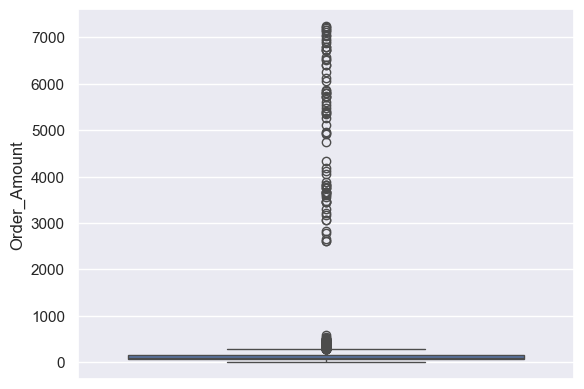

In [26]:
sns.boxplot(ecomm["Order_Amount"])

<Axes: xlabel='Order_Amount', ylabel='Density'>

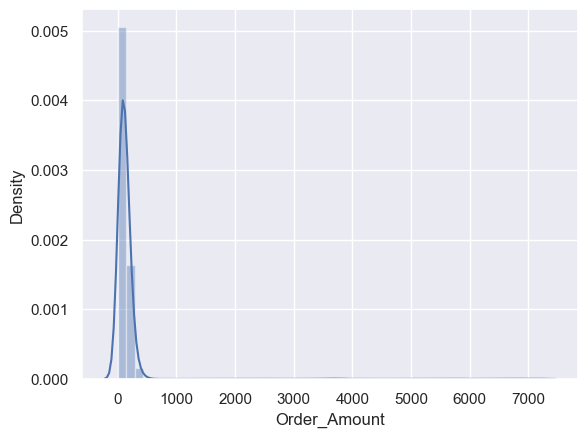

In [27]:
sns.distplot(ecomm["Order_Amount"])

In [28]:
ecomm["Order_Amount"] = ecomm["Order_Amount"].fillna(ecomm["Order_Amount"].median())

### Missing Value Imputation: Quantity
* Imputing missing quantities using the most frequent basket size (mode = 1.0).

In [29]:
ecomm["Quantity"].value_counts()

Quantity
 1.0    4447
 2.0    2884
 3.0    1182
 4.0     560
 5.0     424
 6.0     220
-1.0      90
 0.0      53
Name: count, dtype: int64

In [30]:
ecomm["Quantity"].mode()

0    1.0
Name: Quantity, dtype: float64

In [31]:
ecomm["Quantity"] = ecomm["Quantity"].fillna(ecomm["Quantity"].mode()[0])

### Values transformation in Quantity
* Replacing negative (-1) and zero quantity data.

In [32]:
ecomm["Quantity"] = ecomm["Quantity"].replace((-1,0,0),ecomm["Quantity"].mode()[0])

In [33]:
ecomm["Quantity"].value_counts()

Quantity
1.0    4730
2.0    2884
3.0    1182
4.0     560
5.0     424
6.0     220
Name: count, dtype: int64

In [34]:
ecomm.describe()

,Customer_Age,Order_Amount,Quantity,Customer_Rating,Order_Date,Delivery_Time_Days,Is_Returned
count,10000.000000,10000.000000,10000.000000,9118.000000,10000,9848.000000,9675.000000
mean,36.313400,149.310635,1.972400,3.341632,2024-07-05 01:57:47.520000,3.167648,0.151525
min,18.000000,1.710000,1.000000,1.000000,2023-01-01 00:00:00,1.000000,0.000000
25%,29.000000,62.640000,1.000000,3.000000,2023-10-03 00:00:00,2.000000,0.000000
50%,36.000000,96.940000,2.000000,3.000000,2024-07-10 00:00:00,3.000000,0.000000
75%,43.000000,147.362500,2.000000,4.000000,2025-04-01 06:00:00,4.000000,0.000000
max,75.000000,7236.650000,6.000000,5.000000,2025-12-30 00:00:00,14.000000,1.000000
std,10.849735,455.251665,1.244264,1.161464,NaN,1.797062,0.358578


### Missing Value Imputation: Payment_Method
* Imputing missing payment method.

In [35]:
ecomm["Payment_Method"].value_counts()

Payment_Method
Credit Card             3470
Debit Card              2272
UPI / Digital Wallet    1984
Net Banking              978
Cash on Delivery         770
Name: count, dtype: int64

In [36]:
ecomm["Payment_Method"].mode()[0]

'Credit Card'

In [37]:
ecomm["Payment_Method"] = ecomm["Payment_Method"].fillna(ecomm["Payment_Method"].mode()[0])

### Missing Value Imputation: Customer_Rating
* Imputing missing ratings .

In [38]:
ecomm["Customer_Rating"].value_counts()

Customer_Rating
4.0    3132
3.0    2544
5.0    1422
2.0    1179
1.0     841
Name: count, dtype: int64

In [39]:
ecomm["Customer_Rating"].mode()

0    4.0
Name: Customer_Rating, dtype: float64

In [40]:
ecomm["Customer_Rating"] = ecomm["Customer_Rating"].fillna(ecomm["Customer_Rating"].mode()[0])

### Missing Value Imputation: Delivery_Time_Days
* Imputing missing delivery time days values.

In [41]:
ecomm["Delivery_Time_Days"].value_counts()

Delivery_Time_Days
2.0     2523
3.0     2512
1.0     1466
4.0     1460
5.0     1026
6.0      423
7.0      295
10.0     107
14.0      36
Name: count, dtype: int64

In [42]:
ecomm["Delivery_Time_Days"].mode()[0]

np.float64(2.0)

In [43]:
ecomm["Delivery_Time_Days"].median()

3.0

In [44]:
ecomm["Delivery_Time_Days"] = ecomm["Delivery_Time_Days"].fillna(ecomm["Delivery_Time_Days"].mode()[0])

In [45]:
ecomm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction_ID      10000 non-null  object        
 1   Customer_ID         10000 non-null  object        
 2   Customer_Age        10000 non-null  float64       
 3   Gender              10000 non-null  object        
 4   City                10000 non-null  object        
 5   Product_Category    10000 non-null  object        
 6   Order_Amount        10000 non-null  float64       
 7   Quantity            10000 non-null  float64       
 8   Payment_Method      10000 non-null  object        
 9   Customer_Rating     10000 non-null  float64       
 10  Order_Date          10000 non-null  datetime64[ns]
 11  Delivery_Time_Days  10000 non-null  float64       
 12  Is_Returned         9675 non-null   float64       
dtypes: datetime64[ns](1), float64(6), object(6)
memory u

## Exploratory Data Analysis (EDA) & Visualizations
* Conducting univariate, bivariate, and multivariate analysis .

In [46]:
ecomm.head()

,Transaction_ID,Customer_ID,Customer_Age,Gender,City,Product_Category,Order_Amount,Quantity,Payment_Method,Customer_Rating,Order_Date,Delivery_Time_Days,Is_Returned
0,TXN_100000,CUST_08270,27.0,Female,San Diego,Fashion & Apparel,55.15,1.0,Debit Card,4.0,2025-05-20,7.0,0.0
1,TXN_100001,CUST_01860,26.0,Female,New York,Beauty & Personal Care,174.27,1.0,Cash on Delivery,5.0,2025-03-07,2.0,0.0
2,TXN_100002,CUST_06390,24.0,Male,Houston,Books & Stationery,93.54,2.0,Debit Card,2.0,2023-09-06,4.0,0.0
3,TXN_100003,CUST_06226,47.0,Male,San Antonio,Beauty & Personal Care,103.24,2.0,Credit Card,3.0,2024-11-05,4.0,0.0
4,TXN_100004,CUST_06191,46.0,Female,Houston,Electronics,45.04,1.0,Debit Card,2.0,2024-05-21,4.0,0.0


### Univariate Analysis: Product Category Distribution
* Identifying high-volume sales categories across total orders.

In [47]:
value = ecomm["Product_Category"].value_counts()

In [48]:
value.index

Index(['Fashion & Apparel', 'Electronics', 'Home & Kitchen',
       'Beauty & Personal Care', 'Sports & Outdoors', 'Books & Stationery'],
      dtype='object', name='Product_Category')

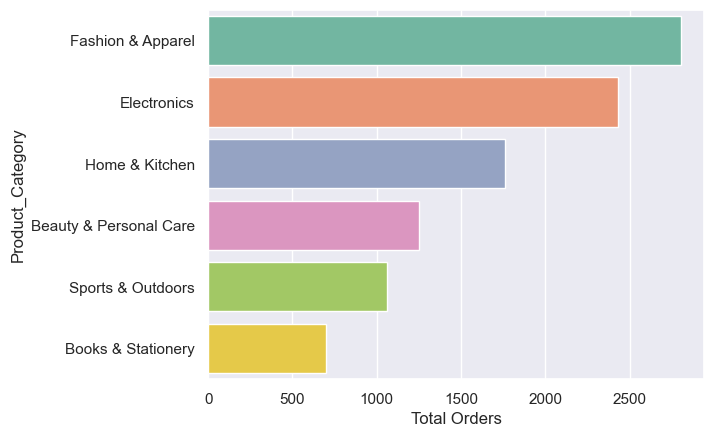

In [49]:
sns.barplot(y=value.index,x=value.values,palette='Set2')
plt.xlabel("Total Orders")
plt.show()

### Univariate Analysis: Customer Age 
* Visualizing the age_wise distribution of the customers.

<Axes: xlabel='Customer_Age', ylabel='Count'>

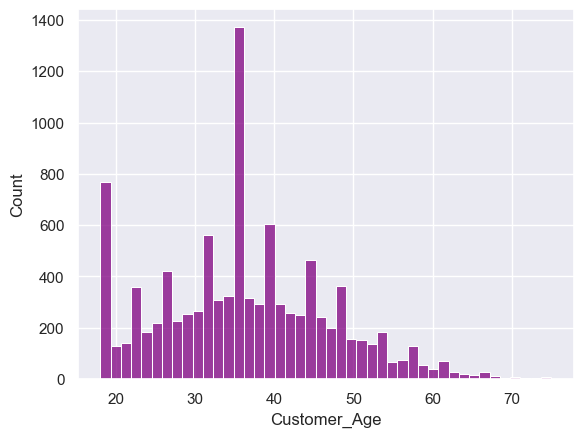

In [50]:
sns.histplot(data=ecomm["Customer_Age"],color='purple')

### Univariate Analysis: Payment Method 
* Comparing transaction volume across digital and traditional payment options.

<Axes: xlabel='count', ylabel='Payment_Method'>

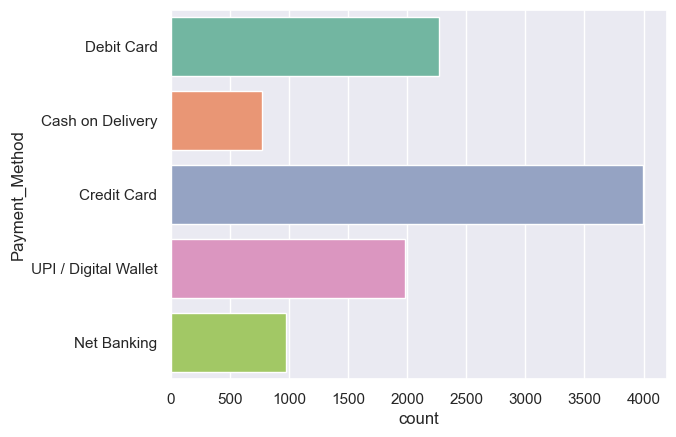

In [51]:
sns.countplot(data=ecomm["Payment_Method"],palette='Set2')

### Multivariate Correlation Analysis
* Linear relationships across numerical variables using a correlation heatmap.

In [52]:
cor = ["Customer_Age","Order_Amount","Quantity","Customer_Rating","Delivery_Time_Days","Is_Returned"]

<Axes: >

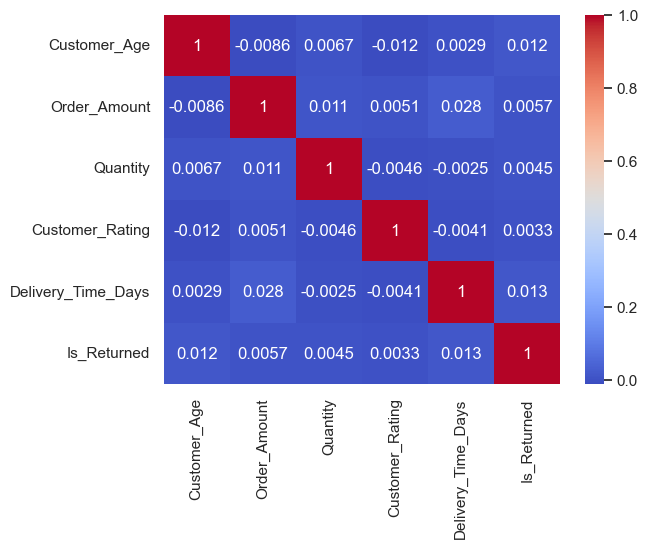

In [53]:
sns.heatmap(ecomm[cor].corr(),annot=True,cmap='coolwarm')

### Bivariate Analysis: Delivery time vs Customer Rating
* Tracking customer satisfaction trends against shipping duration.

<Axes: xlabel='Delivery_Time_Days', ylabel='Customer_Rating'>

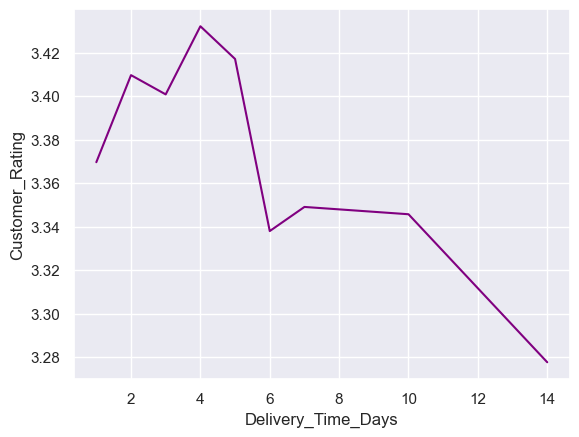

In [55]:
sns.lineplot(data=ecomm, x='Delivery_Time_Days', y='Customer_Rating', errorbar=None,color='purple')

## Key Analyst Findings & Business Recommendations
* **Top Revenue Categories:** Fashion & Apparel and Electronics constitute the largest share of order volume.
* **Demographics:** The primary customer base is concentrated between ages 25 to 45 (median: 36 years).
* **Preferred Payment:** Credit Card (34.7%) and Debit Card (22.7%) drive over 57% of total sales.
* **Logistics & Ratings:** Delivery times within 1–5 days maintain the highest satisfaction scores. Deliveries exceeding 10 days show a direct decline in customer rating.